## Ablation analysis using [Captum](https://captum.ai/api/feature_ablation.html) feature ablation

In [2]:
import sys
!{sys.executable} -m pip install captum

Defaulting to user installation because normal site-packages is not writeable
  Using cached captum-0.8.0-py3-none-any.whl (1.4 MB)


In [9]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

import captum
from captum.attr import FeatureAblation
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Pneumonia

In [5]:
CKPT_DIR = Path("checkpoints_resnet50_pneumonia")
print("Checkpoint dir exists:", CKPT_DIR.exists())
print("Contents:")
for p in CKPT_DIR.iterdir():
    print("  ", p.name)

Checkpoint dir exists: True
Contents:
   resnet50_pneumonia_fold5_best.pth
   resnet50_pneumonia_fold1_best.pth
   resnet50_pneumonia_fold2_best.pth
   resnet50_pneumonia_fold3_best.pth
   resnet50_pneumonia_fold4_best.pth


In [6]:
# EDIT THIS LINE to match one of the filenames printed above
checkpoint_path = CKPT_DIR / "resnet50_pneumonia_fold1_best.pth"

print("Using checkpoint:", checkpoint_path)
assert checkpoint_path.is_file()

Using checkpoint: checkpoints_resnet50_pneumonia/resnet50_pneumonia_fold1_best.pth


In [7]:
def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)

In [10]:
# Build the same architecture you used for training
model = build_model()

# Load checkpoint
ckpt = torch.load(checkpoint_path, map_location=device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
else:
    state_dict = ckpt

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.to(device)
model.eval()

# Quick sanity check: forward
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    out = model(dummy)
print("Model output shape:", out.shape)

Missing keys: []
Unexpected keys: []
Model output shape: torch.Size([1, 1])


In [11]:
def forward_logits(x: torch.Tensor) -> torch.Tensor:
    """
    Forward function for Captum.
    Returns a 1D tensor of shape (N,) with logits for the positive class.
    """
    out = model(x)  # shape: (N, 1) or (N,)
    
    if out.ndim == 2 and out.shape[1] == 1:
        out = out[:, 0]  # (N,)
    
    return out

In [14]:
pred_csv_path = Path("resnet50_pneumonia_cv_test_predictions.csv")
pred_df = pd.read_csv(pred_csv_path)

print(pred_df.columns)
pred_df.head()

Index(['y_true', 'y_prob'], dtype='object')


,y_true,y_prob
0,1,0.938359
1,1,0.624289
2,0,0.724842
3,1,0.584693
4,1,0.756373


In [15]:
pred_csv_path = Path("resnet50_pneumonia_cv_test_predictions.csv")
pred_df = pd.read_csv(pred_csv_path)

print(pred_df.columns)
pred_df.head()

Eligible rows: 209


,y_true,y_prob
0,1,0.846289
1,1,0.803743
2,1,0.899362
3,1,0.942118
4,1,0.868760
5,1,0.937526
6,1,0.979936
7,1,0.868527


In [16]:
# If you already have transforms defined, e.g. val_transform, just do:
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    )
])

In [22]:
images_path = Path("resnet50_pneumonia_test_manifest.csv")
images_df = pd.read_csv(images_path)
images_df.head()

,image_path,pneumonia
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
3,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1
4,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1


In [23]:
N_SAMPLES = 8

subset = images_df.sample(min(N_SAMPLES, len(images_df)), random_state=42).reset_index(drop=True)

print("Subset shape:", subset.shape)
subset.head()

Subset shape: (8, 2)


,image_path,pneumonia
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1
3,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
4,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1


In [24]:
img_tensors = []
loaded_paths = []

for _, row in subset.iterrows():
    img_path = Path(row["image_path"])  # full absolute path from images_df

    if not img_path.is_file():
        raise FileNotFoundError(f"Image not found: {img_path}")
    
    img = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img)   # same transform used during training
    img_tensors.append(tensor)
    loaded_paths.append(str(img_path))

input_batch = torch.stack(img_tensors, dim=0).to(device)

print("input_batch shape:", input_batch.shape)
print("Loaded images:", len(loaded_paths))

input_batch shape: torch.Size([8, 3, 224, 224])
Loaded images: 8


In [25]:
N, C, H, W = input_batch.shape
print("Batch:", N, "Channels:", C, "H,W:", H, W)

# Choose grid size: 14x14 patches over the image
grid_h, grid_w = 14, 14  # 14 * 16 = 224 if your images are 224x224
patch_h, patch_w = H // grid_h, W // grid_w

feature_mask = torch.zeros((1, 1, H, W), dtype=torch.long)

idx = 0
for i in range(grid_h):
    for j in range(grid_w):
        # basic grid tiling; this assumes H and W are divisible by grid_h/grid_w
        h_start, h_end = i * patch_h, (i + 1) * patch_h
        w_start, w_end = j * patch_w, (j + 1) * patch_w
        feature_mask[:, :, h_start:h_end, w_start:w_end] = idx
        idx += 1

feature_mask = feature_mask.to(device)
print("Total features (patches):", idx)

Batch: 8 Channels: 3 H,W: 224 224
Total features (patches): 196


In [27]:
with torch.no_grad():
    out = forward_logits(input_batch)
print(out.shape)

torch.Size([8])


In [28]:
# baseline: black image (all zeros)
baseline = torch.zeros_like(input_batch)

ablator = FeatureAblation(forward_logits)

# Do NOT pass `target` when the model returns a single scalar per sample (shape: (N,))
attributions = ablator.attribute(
    input_batch,
    baselines=baseline,
    feature_mask=feature_mask,
)

print("attributions shape:", attributions.shape)  # expected: (N, C, H, W)

attributions shape: torch.Size([8, 3, 224, 224])


imgs_unnorm: (8, 224, 224, 3)
attr_sum: torch.Size([8, 224, 224])


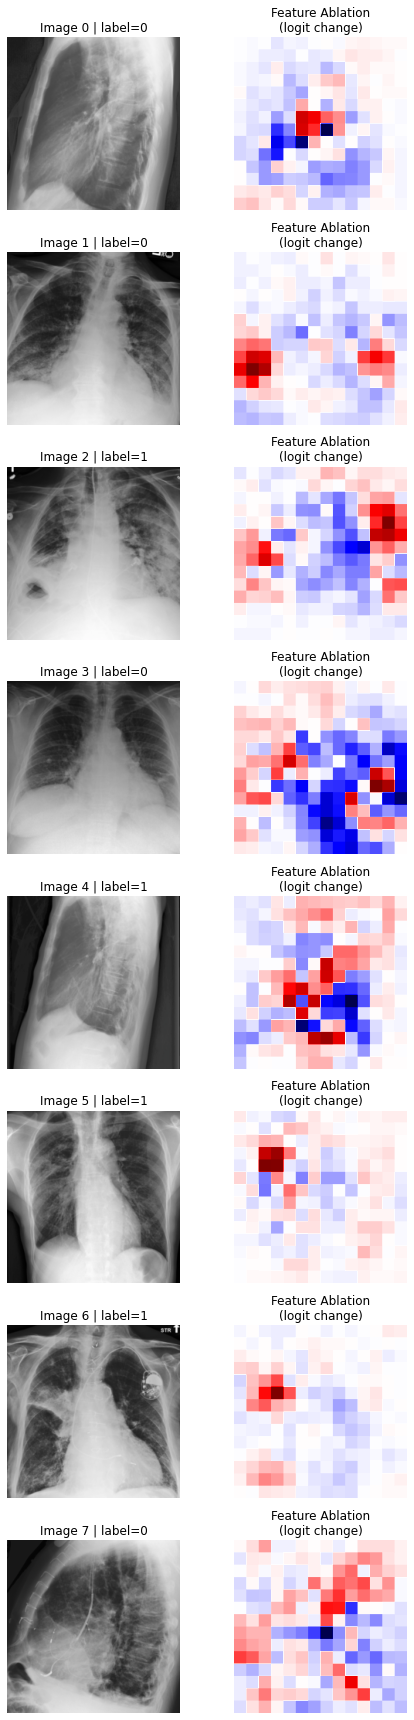

In [29]:
# Unnormalize and visualize
def unnormalize(img_tensor: torch.Tensor) -> torch.Tensor:
    """
    Undo ImageNet normalization:
      mean=[0.485, 0.456, 0.406]
      std=[0.229, 0.224, 0.225]
    img_tensor: (3, H, W) on any device
    """
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_tensor.device).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img

# Move to CPU for plotting
attr = attributions.detach().cpu()      # (N, C, H, W)
imgs = input_batch.detach().cpu()       # (N, C, H, W)

# Aggregate channels: (N, H, W)
attr_sum = attr.sum(dim=1)

# Unnormalize images and convert to HWC
imgs_unnorm = []
for i in range(imgs.shape[0]):
    img = unnormalize(imgs[i])               # (3, H, W)
    img = img.permute(1, 2, 0).numpy()       # (H, W, 3)
    imgs_unnorm.append(img)

imgs_unnorm = np.stack(imgs_unnorm, axis=0)

print("imgs_unnorm:", imgs_unnorm.shape)  # (N, H, W, 3)
print("attr_sum:", attr_sum.shape)        # (N, H, W)

# Plot a few examples
num_to_show = min(8, imgs_unnorm.shape[0])

fig, axes = plt.subplots(num_to_show, 2, figsize=(7, 3 * num_to_show))

if num_to_show == 1:
    axes = np.array([axes])  # make it 2D for consistent indexing

for i in range(num_to_show):
    ax_img = axes[i, 0]
    ax_attr = axes[i, 1]
    
    ax_img.imshow(imgs_unnorm[i])
    # Optional: use label from subset if you want
    label_col = "pneumonia" if "pneumonia" in subset.columns else None
    title = f"Image {i}"
    if label_col is not None:
        title += f" | label={subset.loc[i, label_col]}"
    ax_img.set_title(title)
    ax_img.axis("off")
    
    # normalize colormap around 0 for red/blue
    a = attr_sum[i].numpy()
    m = np.max(np.abs(a)) + 1e-8
    ax_attr.imshow(a, cmap="seismic", vmin=-m, vmax=m)
    ax_attr.set_title("Feature Ablation\n(logit change)")
    ax_attr.axis("off")

plt.tight_layout()
plt.show()

### Pneumothorax

In [30]:
CKPT_DIR = Path("checkpoints_resnet50_pneumothorax")
print("Checkpoint dir exists:", CKPT_DIR.exists())
print("Contents:")
for p in CKPT_DIR.iterdir():
    print("  ", p.name)

Checkpoint dir exists: True
Contents:
   resnet50_pneumothorax_fold1_best.pth
   resnet50_pneumothorax_fold5_best.pth
   resnet50_pneumothorax_fold4_best.pth
   resnet50_pneumothorax_fold2_best.pth
   resnet50_pneumothorax_fold3_best.pth


In [31]:
# EDIT THIS LINE to match one of the filenames printed above
checkpoint_path = CKPT_DIR / "resnet50_pneumothorax_fold1_best.pth"

print("Using checkpoint:", checkpoint_path)
assert checkpoint_path.is_file()

Using checkpoint: checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold1_best.pth


In [32]:
# Build the same architecture you used for training
model = build_model()

# Load checkpoint
ckpt = torch.load(checkpoint_path, map_location=device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
else:
    state_dict = ckpt

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.to(device)
model.eval()

# Quick sanity check: forward
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    out = model(dummy)
print("Model output shape:", out.shape)

Missing keys: []
Unexpected keys: []
Model output shape: torch.Size([1, 1])


In [33]:
pred_csv_path = Path("resnet50_pneumothorax_cv_test_predictions.csv")
pred_df = pd.read_csv(pred_csv_path)

print(pred_df.columns)
pred_df.head()

Index(['y_true', 'y_prob'], dtype='object')


,y_true,y_prob
0,0,0.154789
1,0,0.276797
2,0,0.208555
3,0,0.671858
4,0,0.179872


In [36]:
images_path = Path("resnet50_pneumothorax_test_manifest.csv")
images_df = pd.read_csv(images_path)
images_df.head()

,image_path,pneumothorax
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
3,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
4,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0


In [37]:
N_SAMPLES = 8

subset = images_df.sample(min(N_SAMPLES, len(images_df)), random_state=42).reset_index(drop=True)

print("Subset shape:", subset.shape)
subset.head()

Subset shape: (8, 2)


,image_path,pneumothorax
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
3,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0
4,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0


In [38]:
img_tensors = []
loaded_paths = []

for _, row in subset.iterrows():
    img_path = Path(row["image_path"])  # full absolute path from images_df

    if not img_path.is_file():
        raise FileNotFoundError(f"Image not found: {img_path}")
    
    img = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img)   # same transform used during training
    img_tensors.append(tensor)
    loaded_paths.append(str(img_path))

input_batch = torch.stack(img_tensors, dim=0).to(device)

print("input_batch shape:", input_batch.shape)
print("Loaded images:", len(loaded_paths))

input_batch shape: torch.Size([8, 3, 224, 224])
Loaded images: 8


In [39]:
N, C, H, W = input_batch.shape
print("Batch:", N, "Channels:", C, "H,W:", H, W)

# Choose grid size: 14x14 patches over the image
grid_h, grid_w = 14, 14  # 14 * 16 = 224 if your images are 224x224
patch_h, patch_w = H // grid_h, W // grid_w

feature_mask = torch.zeros((1, 1, H, W), dtype=torch.long)

idx = 0
for i in range(grid_h):
    for j in range(grid_w):
        # basic grid tiling; this assumes H and W are divisible by grid_h/grid_w
        h_start, h_end = i * patch_h, (i + 1) * patch_h
        w_start, w_end = j * patch_w, (j + 1) * patch_w
        feature_mask[:, :, h_start:h_end, w_start:w_end] = idx
        idx += 1

feature_mask = feature_mask.to(device)
print("Total features (patches):", idx)

Batch: 8 Channels: 3 H,W: 224 224
Total features (patches): 196


In [40]:
# baseline: black image (all zeros)
baseline = torch.zeros_like(input_batch)

ablator = FeatureAblation(forward_logits)

# Do NOT pass `target` when the model returns a single scalar per sample (shape: (N,))
attributions = ablator.attribute(
    input_batch,
    baselines=baseline,
    feature_mask=feature_mask,
)

print("attributions shape:", attributions.shape)  # expected: (N, C, H, W)

attributions shape: torch.Size([8, 3, 224, 224])


imgs_unnorm: (8, 224, 224, 3)
attr_sum: torch.Size([8, 224, 224])


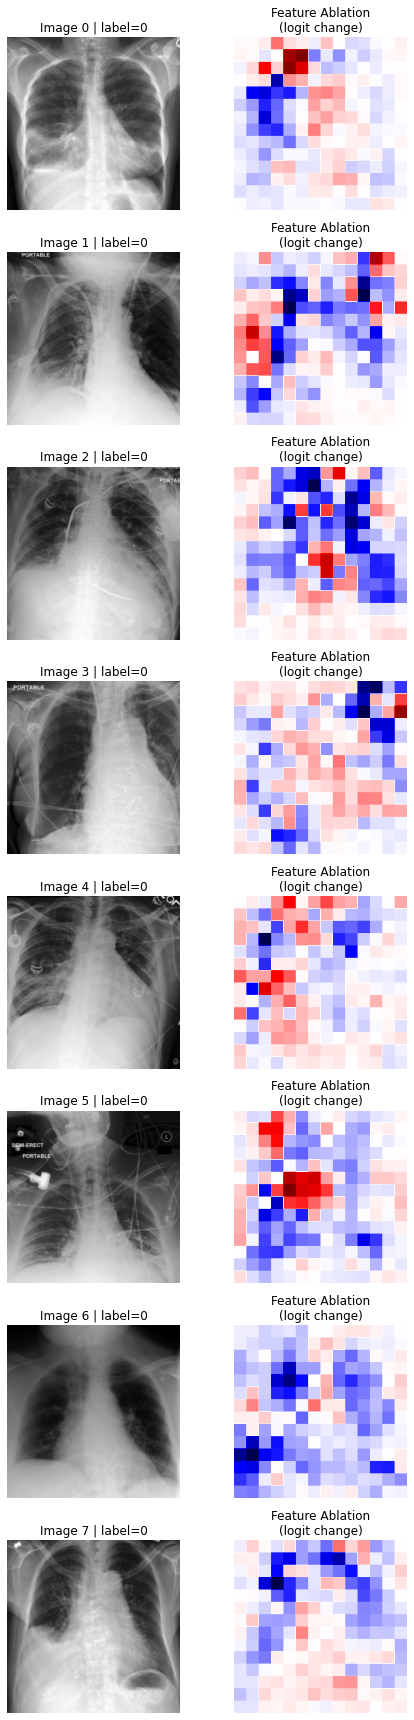

In [41]:
# Move to CPU for plotting
attr = attributions.detach().cpu()      # (N, C, H, W)
imgs = input_batch.detach().cpu()       # (N, C, H, W)

# Aggregate channels: (N, H, W)
attr_sum = attr.sum(dim=1)

# Unnormalize images and convert to HWC
imgs_unnorm = []
for i in range(imgs.shape[0]):
    img = unnormalize(imgs[i])               # (3, H, W)
    img = img.permute(1, 2, 0).numpy()       # (H, W, 3)
    imgs_unnorm.append(img)

imgs_unnorm = np.stack(imgs_unnorm, axis=0)

print("imgs_unnorm:", imgs_unnorm.shape)  # (N, H, W, 3)
print("attr_sum:", attr_sum.shape)        # (N, H, W)

# Plot a few examples
num_to_show = min(8, imgs_unnorm.shape[0])

fig, axes = plt.subplots(num_to_show, 2, figsize=(7, 3 * num_to_show))

if num_to_show == 1:
    axes = np.array([axes])  # make it 2D for consistent indexing

for i in range(num_to_show):
    ax_img = axes[i, 0]
    ax_attr = axes[i, 1]
    
    ax_img.imshow(imgs_unnorm[i])
    # Optional: use label from subset if you want
    label_col = "pneumothorax" if "pneumothorax" in subset.columns else None
    title = f"Image {i}"
    if label_col is not None:
        title += f" | label={subset.loc[i, label_col]}"
    ax_img.set_title(title)
    ax_img.axis("off")
    
    # normalize colormap around 0 for red/blue
    a = attr_sum[i].numpy()
    m = np.max(np.abs(a)) + 1e-8
    ax_attr.imshow(a, cmap="seismic", vmin=-m, vmax=m)
    ax_attr.set_title("Feature Ablation\n(logit change)")
    ax_attr.axis("off")

plt.tight_layout()
plt.show()